# Time-of-Flight depth unwrapping with AdaSwarm 📷

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaSwarm/AdaSwarm/blob/main/examples/tof_depth_unwrapping.ipynb)

A **Time-of-Flight (ToF) depth camera** measures distance from the *phase* of modulated light. At
modulation frequency $f$ the measured phase is $\mathrm{wrap}(k\,d)$ (with $k \propto f$) — so any single
frequency only gives depth within one **unambiguous range**; beyond it the phase wraps and the depth
*aliases*. Real cameras emit **several frequencies** and combine the wrapped phases to disambiguate a
larger range — the same multi-frequency trick as dual-wavelength InSAR, but **per pixel** across a 2D
image.

That per-pixel objective has its global minimum at the true depth but many deceptive alias minima —
exactly where `adaswarm.nn.SwarmLoss(..., per_sample=True)` shines and plain gradient descent fails.

In [1]:
# %pip install "adaswarm[examples] @ git+https://github.com/AdaSwarm/AdaSwarm.git"  # on Colab
import matplotlib.pyplot as plt
import torch

import adaswarm.nn

print("adaswarm", adaswarm.__version__, "| torch", torch.__version__)

K1, K2 = 2.0, 2.9  # per-pixel phase sensitivities for two modulation frequencies

def wrap(a):
    return torch.atan2(torch.sin(a), torch.cos(a))

adaswarm 0.3.0 | torch 2.12.1


## 1. A depth scene and its wrapped phase images

A 40×40 depth map (background ramp, a raised block, a smooth bump). Each frequency sees the depth
*wrapped* — the raw ToF measurement.

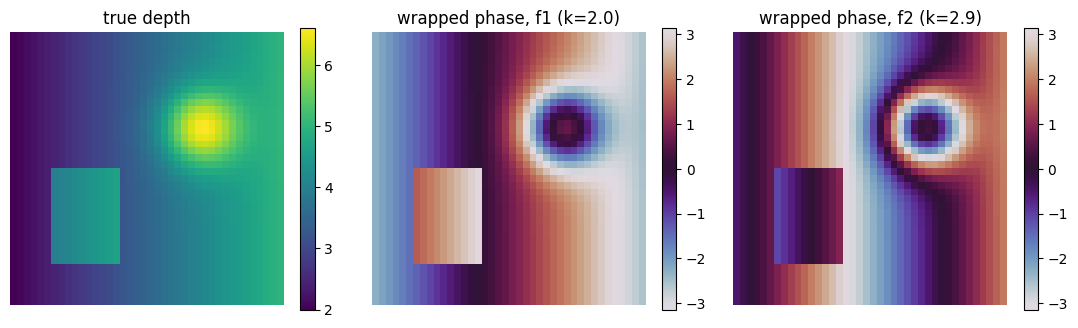

In [2]:
ys, xs = torch.meshgrid(torch.linspace(0, 1, 40), torch.linspace(0, 1, 40), indexing='ij')
d_true = 2.0 + 3.0 * xs
d_true = d_true + 2.5 * torch.exp(-(((xs - 0.7) ** 2 + (ys - 0.35) ** 2) / 0.02))
d_true = d_true + 1.5 * ((xs > 0.15) & (xs < 0.4) & (ys > 0.5) & (ys < 0.85))
psi1, psi2 = wrap(K1 * d_true), wrap(K2 * d_true)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
im0 = ax[0].imshow(d_true, cmap='viridis'); ax[0].set_title('true depth'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(psi1, cmap='twilight'); ax[1].set_title(f'wrapped phase, f1 (k={K1})'); plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(psi2, cmap='twilight'); ax[2].set_title(f'wrapped phase, f2 (k={K2})'); plt.colorbar(im2, ax=ax[2])
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 2. Why it's hard: the per-pixel objective is multi-modal

For each pixel we combine both frequencies:

$$L(d) = \big(1-\cos(k_1 d - \psi_1)\big) + \big(1-\cos(k_2 d - \psi_2)\big).$$

Global minimum at the true depth; deceptive local minima at single-frequency aliases.

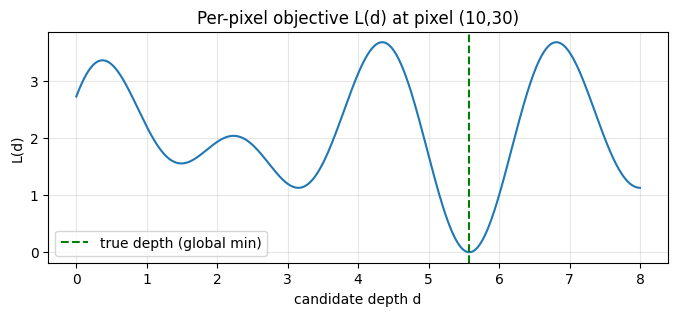

In [3]:
r, c = 10, 30
grid = torch.linspace(0, 8, 800)
L = (1 - torch.cos(K1 * grid - psi1[r, c])) + (1 - torch.cos(K2 * grid - psi2[r, c]))
plt.figure(figsize=(8, 3))
plt.plot(grid, L)
plt.axvline(d_true[r, c].item(), color='g', ls='--', label='true depth (global min)')
plt.title(f'Per-pixel objective L(d) at pixel ({r},{c})')
plt.xlabel('candidate depth d'); plt.ylabel('L(d)'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Recover the depth map: standard Adam vs AdaSwarm

We optimise the depth image directly (each pixel a free parameter) against the wrapped measurements —
once with plain Adam, once with `SwarmLoss(per_sample=True)` (an independent swarm per pixel).

In [4]:
def loss_fn(pred, _target):                      # elementwise, per pixel
    return (1 - torch.cos(K1 * pred - psi1)) + (1 - torch.cos(K2 * pred - psi2))

centre = torch.full_like(d_true, 3.0)

def recover(mode, seed=0, epochs=600, lr=0.05):
    torch.manual_seed(seed)
    d_hat = torch.nn.Parameter(torch.full_like(d_true, 3.0))
    opt = torch.optim.Adam([d_hat], lr=lr)
    crit = adaswarm.nn.SwarmLoss(loss_fn, seed=seed, span=4.0, swarm_size=30,
                                 iterations=60, per_sample=True) if mode == 'adaswarm' else None
    for _ in range(epochs):
        opt.zero_grad()
        loss = crit(d_hat, centre) if mode == 'adaswarm' else loss_fn(d_hat, centre).mean()
        loss.backward()
        opt.step()
    return d_hat.detach()

d_std = recover('standard')
d_ada = recover('adaswarm')
mse = lambda d: ((d - d_true) ** 2).mean().item()
print(f'depth-map MSE  —  standard Adam: {mse(d_std):.3f}   AdaSwarm: {mse(d_ada):.3f}')

depth-map MSE  —  standard Adam: 2.354   AdaSwarm: 0.014


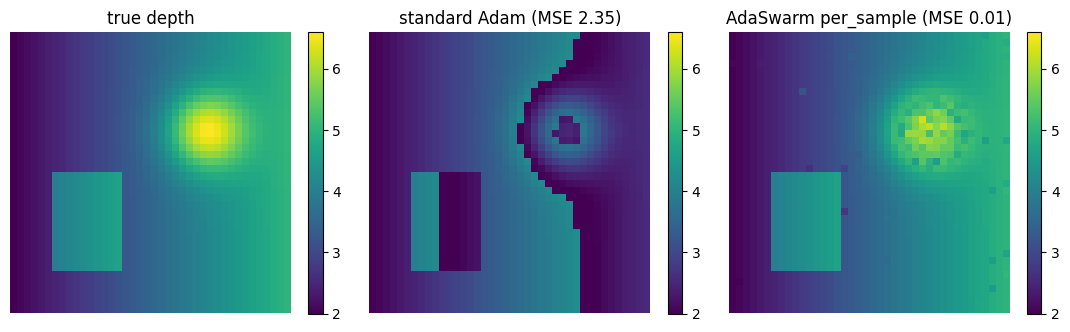

In [5]:
vmin, vmax = float(d_true.min()), float(d_true.max())
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, img, ttl in zip(
    ax,
    [d_true, d_std, d_ada],
    ['true depth', f'standard Adam (MSE {mse(d_std):.2f})', f'AdaSwarm per_sample (MSE {mse(d_ada):.2f})'],
):
    im = a.imshow(img, cmap='viridis', vmin=vmin, vmax=vmax); a.set_title(ttl); a.axis('off')
    plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()

## Takeaways

- **AdaSwarm recovers the depth map** from wrapped ToF phase (MSE ~0.01), while plain Adam is riddled
  with **alias artifacts** (MSE ~2.4) — each pixel trapped in the nearest phase alias.
- The key is **`per_sample=True`**: every one of the 1600 pixels gets its own independent swarm global
  best. That is precisely what per-pixel unwrapping needs.
- **Honest scope:** this works because *two frequencies* make each pixel globally identifiable. It does
  not add a spatial prior — single-frequency dense unwrapping is a different, harder problem.

Same structure appears in **dual-wavelength InSAR** (see
[`insar_phase_unwrapping.ipynb`](insar_phase_unwrapping.ipynb)) and **optical interferometry**. More at
[`docs/use-cases.md`](../docs/use-cases.md).